In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_data

## Load source files

In [3]:
data = load_data()
datasets = list(data.keys())

In [4]:
def get_table(segs):
    total = len(segs)
    table = []
    for i in range(0, segs["breaks_aut"].max()):
        sample = segs[segs["breaks_aut"] >= i].shape[0]
        table.append([i, sample, sample / total * 100])

    table = pd.DataFrame(table, columns=["threshold", "samples", "percentage"])
    return table

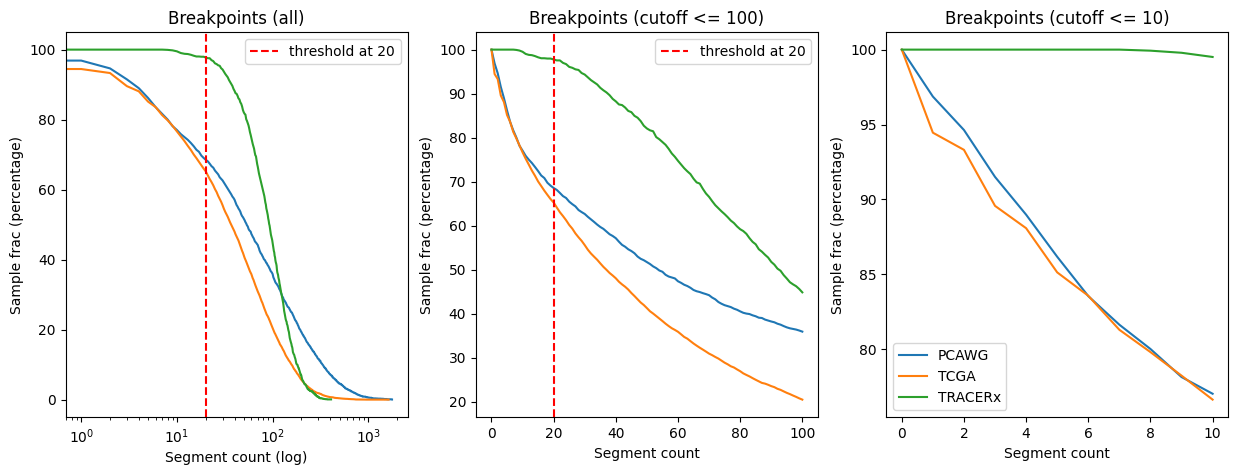

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # Create a figure and a 1x3 subplot
for dataset in datasets:
    table = get_table(data[dataset].samples)

    axs[0].plot(table["threshold"], table["percentage"])   

    selection = table[table["threshold"] <=100]  
    axs[1].plot(selection["threshold"], selection["percentage"])

    selection = table[table["threshold"] <=10]  
    axs[2].plot(selection["threshold"], selection["percentage"])


axs[0].set_xscale('log')
axs[0].set_xlabel("Segment count (log)")
axs[0].set_ylabel("Sample frac (percentage)")
axs[0].set_title(f"Breakpoints (all)")
axs[0].axvline(x=20, color='r', linestyle='--', label="threshold at 20")
axs[0].legend()

axs[1].set_xlabel("Segment count")
axs[1].set_ylabel("Sample frac (percentage)")
axs[1].set_title(f"Breakpoints (cutoff <= 100)")
axs[1].axvline(x=20, color='r', linestyle='--', label="threshold at 20")
axs[1].legend()

axs[2].set_xlabel("Segment count")
axs[2].set_ylabel("Sample frac (percentage)")
axs[2].set_title(f"Breakpoints (cutoff <= 10)")

axs[2].legend(datasets)